In [ ]:
import os
import ast
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.animation as animation

from os import listdir, system
from datetime import datetime
from itertools import product
from pyspark.sql import SparkSession
from pyspark.sql.window import Window
from GDynaDist import Graphs4Distance
from pyspark.sql import types as T
from pyspark.sql import functions as F
from pyspark.sql.functions import col, ceil, udf, substring, sum, to_date, date_format, expr, lit

In [ ]:
# Create Spark session
spark = SparkSession.builder \
    .appName("Data aggregation") \
    .master("local[50]") \
    .config("spark.driver.memory", "30g") \
    .config("spark.executor.memory", "60g") \
    .config("spark.sql.shuffle.partitions", "1000") \
    .getOrCreate()

### Download the dataset

In [ ]:
years = [2024] #[2022, 2023, 2024, 2025]
months = np.arange(12) + 1
days = np.arange(31) + 1

base_name = 'https://movilidad-opendata.mitma.es/estudios_basicos/por-GAU/viajes/ficheros-diarios'

all_files = listdir('/data/big/davidaltamirano/day_by_day_RAW_data/')

for year in years:
    for m in months:
        month = str(m).zfill(2)
        for d in days:
            day = str(d).zfill(2)
            file_name = f'{year}{month}{day}_Viajes_GAU.csv.gz'
            if file_name not in all_files:
                try:
                    print(f'Downloading {year}/{month}/{day}')
                    system(f'wget "{base_name}/{year}-{month}/{file_name}" -P /data/big/davidaltamirano/day_by_day_RAW_data/')
                except:
                    print(f'I failed to download {year}/{month}/{day}')

### Preprocessing

In [ ]:
# Apply a Binomial Distribution to the 'total_trips' of the NA entries in gender column and split into man or woman choices

@udf(T.IntegerType())
def binomial_udf(n):
    if n is None:
        return None
    return int(np.random.binomial(n, 0.5))

def get_random_sample(df_tot, column='weight'):
    # Step 1: Round to top
    df = df_tot.withColumn("W", ceil(col(column).cast("double")))

    # Step 2: Apply the binomial
    df = df.withColumn("w1", binomial_udf(col("W"))) \
           .withColumn("w2", col("W") - col("w1"))

    # Step 3: Create 2 dataframe as output
    df_1 = df.drop("W", "w2").withColumn(column, col("w1")).drop("w1")
    df_2 = df.drop("W", "w1").withColumn(column, col("w2")).drop("w2")

    return df_1, df_2

In [ ]:
# Apply a Multinomial Distribution to the 'total_trips' of the NA entries in age column 
# The probability of each choice ('0-25', '25-45', '45-65', '65-100') is extracted from the original dataset

ages = ['0-25', '25-45', '45-65', '65-100']
probs = [0.24, 0.27, 0.33, 0.16]

# UDF split the trips randomly according the multinomial distribution
@F.udf(returnType=T.ArrayType(T.StructType([
    T.StructField("edad", T.StringType()),
    T.StructField("total_trips", T.DoubleType())
])))
def distribuir_multinomial(total_trips):
    if total_trips is None or total_trips <= 0:
        return []
    # Simulate the Multinomial
    counts = np.random.multinomial(int(round(total_trips)), probs)
    return [{"edad": e, "total_trips": float(c)} for e, c in zip(ages, counts)]

In [ ]:
# Read the dataset by MONTH

year = '2024'
month = '10'
spatial = 'distritos'  # choices: distritos, municipios, GAU

all_files = f'/data/big/davidaltamirano/day_by_day_RAW_data/{year}{month}*_Viajes_{spatial}.csv.gz'
raw_df = spark.read \
    .option("header", True) \
    .option("inferSchema", True) \
    .option("delimiter", "|") \
    .csv(all_files)

In [ ]:
# Delete the entries of the dataset with areas outside of Spain as origin or destination

abroad_areas_df = pd.read_csv('/data/big/davidaltamirano/areas_out_Spain.csv')
abroad_areas = list(abroad_areas_df['ID'])  # number of areas outside of Spain = 118

df_to_study = raw_df.filter(
    (~F.col("origen").isin(abroad_areas)) & 
    (~F.col("destino").isin(abroad_areas))
)

In [ ]:
# Apply the Binomial to gender column

df_NA = df_to_study.filter(col('sexo') == 'NA')
df_WM = df_to_study.filter(col('sexo') != 'NA')

df_NA = df_NA.filter(col('viajes') != 0)
df_1, df_2 = get_random_sample(df_NA, 'viajes')

df_women = df_1.replace('NA', 'mujer', subset=['sexo'])
df_men = df_2.replace('NA', 'hombre', subset=['sexo'])

df = df_WM.unionByName(df_women).unionByName(df_men)

df_to_study = df.groupBy('fecha', 'periodo', 'origen', 'destino', 'distancia', 'actividad_origen', 'actividad_destino', 'residencia', 'renta', 'edad', 'sexo').agg(sum('viajes').alias('total_trips'), sum('viajes_km').alias('total_km'))

In [ ]:
# Apply the Multinomial to age column

df_NA = df_to_study.filter(col('edad') == 'NA')
df_age = df_to_study.filter(col('edad') != 'NA')

df_expanded = df_NA.filter(col('total_trips') != 0)
df_expanded = df_expanded.withColumn("edad_dist", distribuir_multinomial(F.col("total_trips")))
df_expanded = df_expanded.withColumn("edad_dist", F.explode("edad_dist"))

df_expanded = df_expanded.withColumn("edad", F.col("edad_dist.edad")) \
                         .withColumn("total_trips", F.col("edad_dist.total_trips")) \
                         .drop("edad_dist")
df_expanded = df_expanded.filter(col('total_trips') != 0)

df = df_age.unionByName(df_expanded)

#df_to_study = df.groupBy('fecha', 'periodo', 'origen', 'destino', 'distancia', 'actividad_origen', 'actividad_destino', 'residencia', 'renta', 'edad', 'sexo').agg(sum('total_trips').alias('total_trips'), sum('total_km').alias('total_km'))

In [ ]:
# Save the refined dataset in a file .parquet

df_to_study = df

# Address where to store the new DataFrame
storage_route = f'/data/big/davidaltamirano/data_aggregation_refined/{spatial}/{year}{month}/'

# Save the new aggregated DataFrame in a compressed .parquet file
df_to_study.write \
.option("compression", "snappy") \
.mode("overwrite") \
.parquet(storage_route)

In [ ]:
# Apply the preprocessing by day

# List all the *_Viajes_distritos.csv.gz files in 2024
all_raw_files = os.listdir("/data/big/davidaltamirano/day_by_day_RAW_data/")
files_to_study = [f for f in all_raw_files if f.startswith("2024") and f.endswith("_Viajes_distritos.csv.gz")]

for file in files_to_study:
    if f'{file[0:8]}_Trips_districts.parquet' in os.listdir("/data/big/davidaltamirano/data_refined_by_day/"):
        continue

    raw_df = spark.read \
                  .option("header", True) \
                  .option("inferSchema", True) \
                  .option("delimiter", "|") \
                  .csv(f"/data/big/davidaltamirano/day_by_day_RAW_data/{file}")
    

    # Eliminate the zones outside of Spain
    abroad_areas_df = pd.read_csv('/data/big/davidaltamirano/areas_out_Spain.csv')
    abroad_areas = list(abroad_areas_df['ID'])  # son todos las zonas fuera de españa == 118

    # Delete the rows with the areas outside Spain in origin or destination
    df_to_study = raw_df.filter(
        (~F.col("origen").isin(abroad_areas)) & 
        (~F.col("destino").isin(abroad_areas))
    )


    # Distribute NA entries for gender 
    df_NA = df_to_study.filter(col('sexo') == 'NA')
    df_WM = df_to_study.filter(col('sexo') != 'NA')

    df_NA = df_NA.filter(col('viajes') != 0)
    df_1, df_2 = get_random_sample(df_NA, 'viajes')

    df_women = df_1.replace('NA', 'mujer', subset=['sexo'])
    df_men = df_2.replace('NA', 'hombre', subset=['sexo'])

    df = df_WM.unionByName(df_women).unionByName(df_men)

    df_to_study = df.groupBy('fecha', 'periodo', 'origen', 'destino', 'distancia', 'actividad_origen', 'actividad_destino', 'residencia', 'renta', 'edad', 'sexo').agg(sum('viajes').alias('total_trips'), sum('viajes_km').alias('total_km'))


    # Distribute NA entries for age
    df_NA = df_to_study.filter(col('edad') == 'NA')
    df_age = df_to_study.filter(col('edad') != 'NA')

    df_expanded = df_NA.withColumn("edad_dist", distribuir_multinomial(F.col("total_trips")))
    df_expanded = df_expanded.withColumn("edad_dist", F.explode("edad_dist"))

    df_expanded = df_expanded.withColumn("edad", F.col("edad_dist.edad")) \
                            .withColumn("total_trips", F.col("edad_dist.total_trips")) \
                            .drop("edad_dist")
    df_expanded = df_expanded.filter(col('total_trips') != 0)

    df = df_age.unionByName(df_expanded)

    df_to_study = df.groupBy('fecha', 'periodo', 'origen', 'destino', 'distancia', 'actividad_origen', 'actividad_destino', 'residencia', 'renta', 'edad', 'sexo').agg(sum('total_trips').alias('total_trips'), sum('total_km').alias('total_km'))


    # Save the dataframes
    storage_route = f'/data/big/davidaltamirano/data_refined_by_day/{file[0:8]}_Trips_districts.parquet'
    df_to_study.write \
    .option("compression", "snappy") \
    .mode("overwrite") \
    .parquet(storage_route)

### Analysis of differences

In [ ]:
def Mapping_for_Embeddding(df):
    nodes_O = df.select(F.col('origen').alias('node'))
    nodes_D = df.select(F.col('destino').alias('node'))

    nodes = nodes_O.union(nodes_D).distinct()

    nodes_dict = {row['node']: idx for idx, row in enumerate(nodes.collect())}
    n = len(nodes_dict)

    # Mapping values to indexes
    def map_to_index(value):
        return nodes_dict.get(value, 0)  # Return '0' if it is not in the dict

    map_udf = udf(map_to_index, T.IntegerType())

    # Add two new columns with the index of the zones   
    df = df.withColumn('origin_id', map_udf('origen')).withColumn('destination_id', map_udf('destino'))

    return df, n

In [ ]:
# Load the dataset and aggregate according what to study
refined_df = spark.read.parquet('/data/big/davidaltamirano/data_refined_by_day/2024*_Trips_districts.parquet')

# Aggregate the dataset based on the study case
df_to_study = (refined_df.groupBy("fecha", "periodo", "origen", "destino", "actividad_origen", "actividad_destino", "sexo")
               .agg(sum("total_trips").alias("total_trips")))

**GENERAL PICTURE**

In [ ]:
original_file_name = f'/data/big/davidaltamirano/results/refined/distances_2024_districts.csv'

for day in [row.fecha for row in df_to_study.select('fecha').distinct().collect()]:
    
    df_to_study_daily = df_to_study.filter(col("fecha") == day)
    df_to_study_daily, n = Mapping_for_Embeddding(df_to_study_daily)

    # Split the dataset into man and women
    df_woman = df_to_study_daily.filter(col('sexo') == 'mujer')
    df_man = df_to_study_daily.filter(col('sexo') == 'hombre')

    # Select the origin, destination, time and weight columns (global transition matrix) and rewrite to i, j, t and τ
    pd_df_woman = df_woman.select(col('origin_id').alias('i'), col('destination_id').alias('j'), col('periodo').alias('t'), col('total_trips').alias('\u03C4')).toPandas()
    pd_df_man = df_man.select(col('origin_id').alias('i'), col('destination_id').alias('j'), col('periodo').alias('t'), col('total_trips').alias('\u03C4')).toPandas()

    n_trips_W = np.sum(pd_df_woman['\u03C4'])
    n_trips_M = np.sum(pd_df_man['\u03C4'])
    edgesM = len(pd_df_man)
    edgesW = len(pd_df_woman)
    nodesW = len(pd.concat([pd_df_woman['i'], pd_df_woman['j']]).unique())
    nodesM = len(pd.concat([pd_df_man['i'], pd_df_man['j']]).unique())

    nodes = np.arange(n)
    Data = Graphs4Distance(verbose=0)
    # Loading the dataset
    Data.LoadDataset(pd_df_man, 'graph_man', nodes=nodes)        # taumin=1, t_agg=24, symmetric=False
    Data.LoadDataset(pd_df_woman, 'graph_woman', nodes=nodes)    # taumin=1, t_agg=24

    dist = Data.GetDistance('graph_man', 'graph_woman', distance_type = 'matched', node_mapping = 'Same')
    
    # Save the results
    if not os.path.exists(original_file_name):
        with open(original_file_name, "w") as f:
            f.write("day,nodesW,nodesM,edgesW,edgesM,n_trips_W,n_trips_M,distance\n")

    with open(original_file_name, 'a') as f:
        f.write(f"{day},{nodesW},{nodesM},{edgesW},{edgesM},{n_trips_W},{n_trips_M},{dist}\n")

**DAY / NIGHT**

In [ ]:
def calc_sunrise(lat, lon, date):
    if lat is None or lon is None or date is None:
        return None
    try:
        loc = LocationInfo(latitude=float(lat), longitude=float(lon))
        s = sun(loc.observer, date=date)
        return s['sunrise'].hour
    except:
        return None

udf_sunrise = udf(calc_sunrise, T.IntegerType())


def calc_sunset(lat, lon, date):
    if lat is None or lon is None or date is None:
        return None
    try:
        loc = LocationInfo(latitude=float(lat), longitude=float(lon))
        s = sun(loc.observer, date=date)
        return s['sunset'].hour
    except:
        return None

udf_sunset = udf(calc_sunset, T.IntegerType())

In [ ]:
refined_df = spark.read.parquet('/data/big/davidaltamirano/data_refined_by_day/2024*_Trips_districts.parquet')

df_to_study = (refined_df.groupBy("fecha", "periodo", "origen", "destino", "sexo")
               .agg(sum("total_trips").alias("total_trips")))

refined_df = df_to_study.withColumn("date", to_date(col("fecha").cast("string"), "yyyyMMdd"))


gdf = gpd.read_file('/data/big/davidaltamirano/zonificacion_distritos/zonificacion_distritos.shp')
gdf = gdf.to_crs(epsg=4326)
gdf["lon"] = gdf.centroid.x
gdf["lat"] = gdf.centroid.y
gdf = gdf.drop('geometry', axis=1)
coords_spark = spark.createDataFrame(gdf)


refined_df = refined_df.join(coords_spark, refined_df.origen == coords_spark.ID, "left")


refined_df = (
    refined_df.withColumn("sunrise", udf_sunrise(col("lat"), col("lon"), col("date")))
      .withColumn("sunset", udf_sunset(col("lat"), col("lon"), col("date")))
)

In [ ]:
df_to_study = refined_df.drop('date', 'ID', 'lon', 'lat')

df_day = df_to_study.filter((col("periodo") >= col('sunrise')) & (col("periodo") <= col('sunset')))

night_part1 = df_to_study.filter(col("periodo") > col('sunset'))
night_part2 = df_to_study.filter(col("periodo") < col('sunrise')).withColumn("fecha", date_format(to_date(col("fecha"), "yyyyMMdd") - expr("INTERVAL 1 DAY"), "yyyyMMdd")).withColumn('periodo', col('periodo')+24)
df_night = night_part1.unionByName(night_part2)

In [ ]:
df_day.write \
.option("compression", "snappy") \
.mode("overwrite") \
.parquet('/data/big/davidaltamirano/data_aggregation_refined/distritos/2024_day/')


df_night.write \
.option("compression", "snappy") \
.mode("overwrite") \
.parquet('/data/big/davidaltamirano/data_aggregation_refined/distritos/2024_night/')

In [ ]:
dfs_to_study = [df_day, df_night]
original_file_name = f'/data/big/davidaltamirano/results/refined/distances_2024_districts_day_night.csv'

for k, df_to_study in enumerate(dfs_to_study):
    for day in [row.fecha for row in df_to_study.select('fecha').distinct().collect()]:

        df_to_study_daily = df_to_study.filter(col('fecha') == day)
        df_to_study_daily, n = Mapping_for_Embeddding(df_to_study_daily)

        # Split the dataset into n (choices of the aggregation parameter) datasets
        df_woman = df_to_study_daily.filter(col('sexo') == 'mujer')
        df_man = df_to_study_daily.filter(col('sexo') == 'hombre')

        # Select the origin, destination, time and weight columns (global transition matrix) and rewrite to i, j, t and τ
        pd_df_woman = df_woman.select(col('origin_id').alias('i'), col('destination_id').alias('j'), col('periodo').alias('t'), col('total_trips').alias('\u03C4')).toPandas()
        pd_df_man = df_man.select(col('origin_id').alias('i'), col('destination_id').alias('j'), col('periodo').alias('t'), col('total_trips').alias('\u03C4')).toPandas()

        n_trips_W = np.sum(pd_df_woman['\u03C4'])
        n_trips_M = np.sum(pd_df_man['\u03C4'])
        edgesM = len(pd_df_man)
        edgesW = len(pd_df_woman)
        nodesW = len(pd.concat([pd_df_woman['i'], pd_df_woman['j']]).unique())
        nodesM = len(pd.concat([pd_df_man['i'], pd_df_man['j']]).unique())

        nodes = np.arange(n)
        Data = Graphs4Distance(verbose=0)
        # Loading the dataset
        Data.LoadDataset(pd_df_man, 'graph_man', nodes=nodes)
        Data.LoadDataset(pd_df_woman, 'graph_woman', nodes=nodes)

        dist = Data.GetDistance('graph_man', 'graph_woman', distance_type = 'matched', node_mapping = 'Same')

        # Save the results
        if not os.path.exists(original_file_name):
            with open(original_file_name, "w") as f:
                f.write("day,day_night,nodesW,nodesM,edgesW,edgesM,n_trips_W,n_trips_M,distance\n")

        with open(original_file_name, 'a') as f:
            f.write(f"{day},{k},{nodesW},{nodesM},{edgesW},{edgesM},{n_trips_W},{n_trips_M}{dist}\n")

**ACTIVITY PURPOSES**

In [ ]:
original_file_name = f'/data/big/davidaltamirano/results/refined/distances_2024_districts_activity_purposes_pairs.csv'

activity_purpose = ['casa', 'trabajo_estudio', 'frecuente', 'no_frecuente'] 

for purpose1 in activity_purpose:
    for purpose2 in activity_purpose:
        if purpose1 == purpose2:
            continue
        
        df_to_study_activity = df_to_study.filter((col('actividad_origen') == purpose1) & (col('actividad_destino') == purpose2))

        for day in [row.fecha for row in df_to_study_activity.select('fecha').distinct().collect()]:
            
            df_to_study_daily = df_to_study_activity.filter(col("fecha") == day)
            df_to_study_daily, n = Mapping_for_Embeddding(df_to_study_daily)

            # Split the dataset into man and women
            df_woman = df_to_study_daily.filter(col('sexo') == 'mujer')
            df_man = df_to_study_daily.filter(col('sexo') == 'hombre')

            # Select the origin, destination, time and weight columns (global transition matrix) and rewrite to i, j, t and τ
            pd_df_woman = df_woman.select(col('origin_id').alias('i'), col('destination_id').alias('j'), col('periodo').alias('t'), col('total_trips').alias('\u03C4')).toPandas()
            pd_df_man = df_man.select(col('origin_id').alias('i'), col('destination_id').alias('j'), col('periodo').alias('t'), col('total_trips').alias('\u03C4')).toPandas()

            n_trips_W = np.sum(pd_df_woman['\u03C4'])
            n_trips_M = np.sum(pd_df_man['\u03C4'])
            edgesM = len(pd_df_man)
            edgesW = len(pd_df_woman)
            nodesW = len(pd.concat([pd_df_woman['i'], pd_df_woman['j']]).unique())
            nodesM = len(pd.concat([pd_df_man['i'], pd_df_man['j']]).unique())

            nodes = np.arange(n)
            Data = Graphs4Distance(verbose=0)
            # Loading the dataset
            Data.LoadDataset(pd_df_man, 'graph_man', nodes=nodes)        # taumin=1, t_agg=24, symmetric=False
            Data.LoadDataset(pd_df_woman, 'graph_woman', nodes=nodes)    # taumin=1, t_agg=24

            dist = Data.GetDistance('graph_man', 'graph_woman', distance_type = 'matched', node_mapping = 'Same')
            
            # Save the results
            if not os.path.exists(original_file_name):
                with open(original_file_name, "w") as f:
                    f.write("day,nodesW,nodesM,edgesW,edgesM,purpose_origin,purpose_destination,n_trips_W,n_trips_M,distance\n")

            with open(original_file_name, 'a') as f:
                f.write(f"{day},{nodesW},{nodesM},{edgesW},{edgesM},{purpose1},{purpose2},{n_trips_W},{n_trips_M},{dist}\n")

**Study Case: 'GAU Valencia'**

In [ ]:
original_file_name = f'/data/big/davidaltamirano/results/refined/distances_2024_GAU_Valencia.csv'
zones_relation = pd.read_csv('/data/big/davidaltamirano/relacion_ine_zonificacionMitma.csv', delimiter='|')
districts_inside = list(zones_relation[zones_relation.gau_mitma == 'GAU Valencia']['distrito_mitma'].unique())

inside = ['no']

for ins in inside:
    if ins == 'yes':
        df_to_study_city = df_to_study.filter((~F.col("origen").isin(districts_inside)) & (~F.col("destino").isin(districts_inside)))
    else:
        df_to_study_city = df_to_study.filter((~F.col("origen").isin(districts_inside)) | (~F.col("destino").isin(districts_inside)))

    for day in [row.fecha for row in df_to_study_city.select('fecha').distinct().collect()]:        
        df_to_study_daily = df_to_study_city.filter(col("fecha") == day)
        df_to_study_daily, n = Mapping_for_Embeddding(df_to_study_daily)

        # Split the dataset into man and women
        df_woman = df_to_study_daily.filter(col('sexo') == 'mujer')
        df_man = df_to_study_daily.filter(col('sexo') == 'hombre')

        # Select the origin, destination, time and weight columns (global transition matrix) and rewrite to i, j, t and τ
        pd_df_woman = df_woman.select(col('origin_id').alias('i'), col('destination_id').alias('j'), col('periodo').alias('t'), col('total_trips').alias('\u03C4')).toPandas()
        pd_df_man = df_man.select(col('origin_id').alias('i'), col('destination_id').alias('j'), col('periodo').alias('t'), col('total_trips').alias('\u03C4')).toPandas()

        n_trips_W = np.sum(pd_df_woman['\u03C4'])
        n_trips_M = np.sum(pd_df_man['\u03C4'])
        edgesM = len(pd_df_man)
        edgesW = len(pd_df_woman)
        nodesW = len(pd.concat([pd_df_woman['i'], pd_df_woman['j']]).unique())
        nodesM = len(pd.concat([pd_df_man['i'], pd_df_man['j']]).unique())

        nodes = np.arange(n)
        Data = Graphs4Distance(verbose=0)
        # Loading the dataset
        Data.LoadDataset(pd_df_man, 'graph_man', nodes=nodes)        # taumin=1, t_agg=24, symmetric=False
        Data.LoadDataset(pd_df_woman, 'graph_woman', nodes=nodes)    # taumin=1, t_agg=24

        dist = Data.GetDistance('graph_man', 'graph_woman', distance_type = 'matched', node_mapping = 'Same')
        
        # Save the results
        if not os.path.exists(original_file_name):
            with open(original_file_name, "w") as f:
                f.write("inside,day,nodesW,nodesM,edgesW,edgesM,n_trips_W,n_trips_M,distance\n")

        with open(original_file_name, 'a') as f:
            f.write(f"{ins},{day},{nodesW},{nodesM},{edgesW},{edgesM},{n_trips_W},{n_trips_M},{dist}\n")

### Results

**DAY / NIGHT**

- day = [8, ..., 17]
- night = [18, ..., 7]

In [ ]:
df_day = df_to_study.filter(col("periodo").between(8, 17))

night_part1 = df_to_study.filter(col("periodo").between(18, 23))
night_part2 = df_to_study.filter(col("periodo").between(0, 7)).withColumn("fecha", date_format(to_date(col("fecha"), "yyyyMMdd") - expr("INTERVAL 1 DAY"), "yyyyMMdd")).withColumn('periodo', col('periodo')+24)
df_night = night_part1.unionByName(night_part2)
df_night = df_night.filter((col("fecha") >= lit("20241001")) & (col("fecha") <= lit("20241230")))

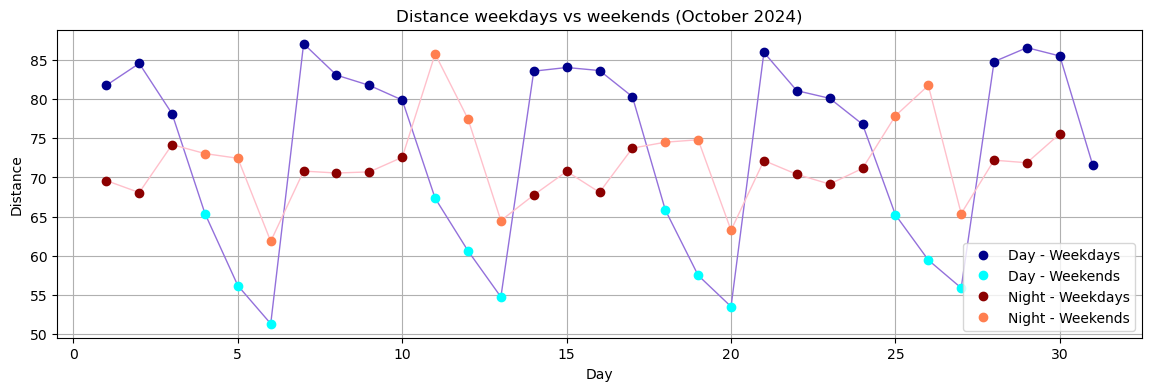

In [2]:
actual_gaus = pd.read_csv('/data/big/davidaltamirano/results/backup2/actual_distances_oct_sexo_fullDF_gaus.csv')
actual_distances_day = pd.read_csv('/data/big/davidaltamirano/results/actual_distances_oct_gaus_1_NOabroad_day.csv')
actual_distances_night = pd.read_csv('/data/big/davidaltamirano/results/actual_distances_oct_gaus_1_NOabroad_night.csv')

actual_distances_day["fecha"] = pd.to_datetime("2024-10-" + actual_distances_day["day"].astype(str).str.zfill(2))
actual_distances_day["weekday"] = actual_distances_day["fecha"].dt.weekday 
df_weekdays_day = actual_distances_day[actual_distances_day["weekday"].isin([0, 1, 2, 3])]
df_weekends_day = actual_distances_day[actual_distances_day["weekday"].isin([4, 5, 6])]

actual_distances_night["fecha"] = pd.to_datetime("2024-10-" + actual_distances_night["day"].astype(str).str.zfill(2))
actual_distances_night["weekday"] = actual_distances_night["fecha"].dt.weekday 
df_weekdays_night = actual_distances_night[actual_distances_night["weekday"].isin([0, 1, 2, 3])]
df_weekends_night = actual_distances_night[actual_distances_night["weekday"].isin([4, 5, 6])]

# Graficar
plt.figure(figsize=(14,4))
plt.plot(actual_distances_day.groupby('day').mean()["distance"], color='mediumpurple', linewidth=1)
plt.plot(df_weekdays_day.groupby('day').mean()["distance"], 'o', color='darkblue', label="Day - Weekdays")
plt.plot(df_weekends_day.groupby('day').mean()["distance"], 'o', color='cyan', label="Day - Weekends")
plt.plot(actual_distances_night.groupby('day').mean()["distance"], color='pink', linewidth=1)
plt.plot(df_weekdays_night.groupby('day').mean()["distance"], 'o', color='darkred', label="Night - Weekdays")
plt.plot(df_weekends_night.groupby('day').mean()["distance"], 'o', color='coral', label="Night - Weekends")
#plt.plot(df_weekdays["day"], df_weekdays["distance"], label="Entre semana (L-J)")
#plt.plot(df_weekends["day"], df_weekends["distance"], label="Fin de semana (V-D)")
plt.xlabel("Day")
plt.ylabel("Distance")
plt.title("Distance weekdays vs weekends (October 2024)")
plt.legend()
plt.grid(True)
plt.show()

**ACTIVITY PURPOSE**

- "casa"
- "trabajo_estudio"
- "frecuente"
- "no_frecuente".

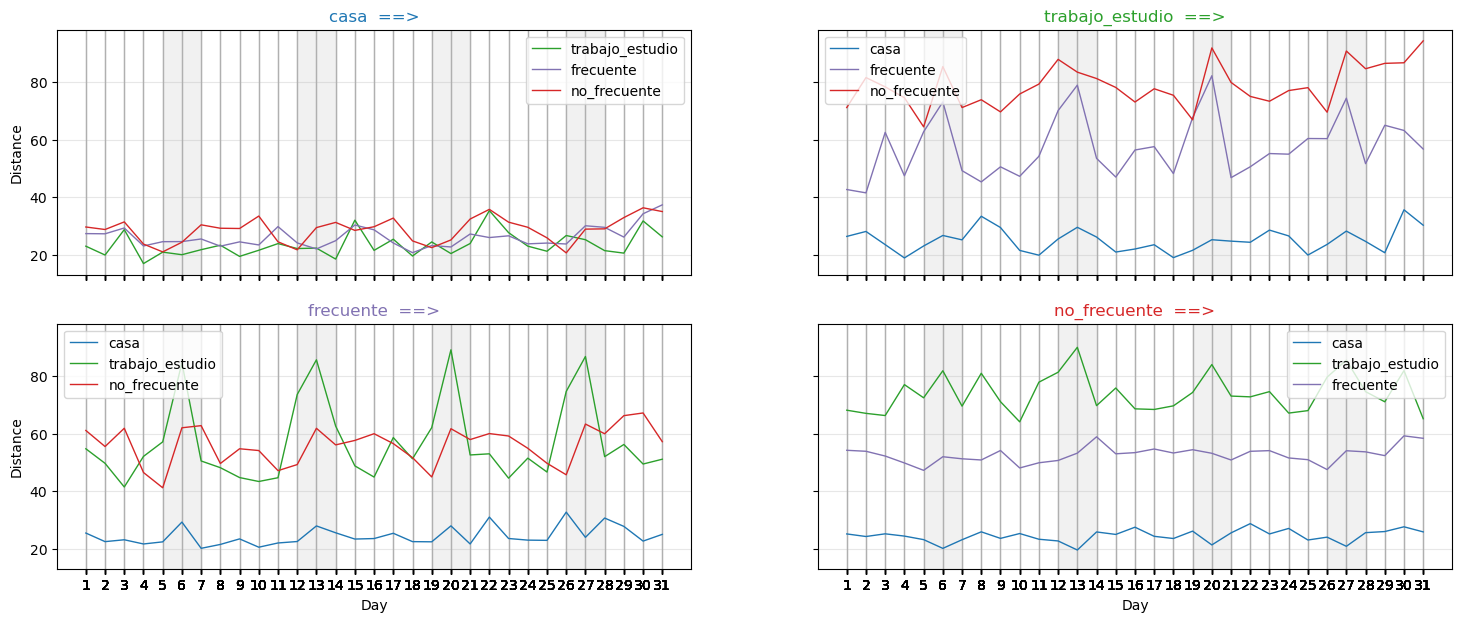

In [3]:
# GAU's
activities = {'casa': '#1f77b4', 'trabajo_estudio': '#2ca02c', 'frecuente': '#8172B2', 'no_frecuente': '#d62728'}
activity_purposes_pairs_distance_V3 = pd.read_csv('/data/big/davidaltamirano/results/actual_distances_oct_gaus_activity_purposes_pairsV3.csv')
activity_purposes_pairs_distance_V3['date'] = [f'202410{str(i).zfill(2)}' for i in activity_purposes_pairs_distance_V3.day]
activity_purposes_pairs_distance_V3['datetime'] = pd.to_datetime(activity_purposes_pairs_distance_V3['date'], format='%Y%m%d')
activity_purposes_pairs_distance_V3['day_name'] = activity_purposes_pairs_distance_V3['datetime'].dt.strftime('%a')
activity_purposes_pairs_distance_V3['n_trips'] = activity_purposes_pairs_distance_V3.n_trips_W + activity_purposes_pairs_distance_V3.n_trips_M
activity_purposes_pairs_distance_V3["purpose_pair"] = activity_purposes_pairs_distance_V3["purpose_origin"] + " → " + activity_purposes_pairs_distance_V3["purpose_destination"]


fig, ax = plt.subplots(2, 2, figsize=(18, 7), sharex=True, sharey=True)
ax = ax.flatten()

for idx, act1 in enumerate(activities.keys()):
    O_purpose_distance = activity_purposes_pairs_distance_V3[activity_purposes_pairs_distance_V3.purpose_origin == act1]
    row, col = divmod(idx, 2)
    for act2 in activities.keys():
        if act1 == act2:
            continue

        OD_purpose_distance = O_purpose_distance[O_purpose_distance.purpose_destination == act2].groupby('datetime')['distance'].mean()

        ax[idx].plot(OD_purpose_distance, label=f"{act2}", color=activities[act2], linewidth=1)

    ax[idx].set_title(f"{act1}  ==>", color=list(activities.values())[idx])
    ax[idx].grid(alpha=0.3)
    ax[idx].legend()
    
    if row == 1:
        ax[idx].set_xlabel("Day")
    if col == 0:  
        ax[idx].set_ylabel("Distance")

    if not OD_purpose_distance.empty and pd.api.types.is_datetime64_any_dtype(OD_purpose_distance.index):
        for date in OD_purpose_distance.index:
            if date.weekday() >= 5: 
                ax[idx].axvspan(date, date + pd.Timedelta(days=1),
                                color='lightgrey', alpha=0.3)

plt.xticks(ticks=activity_purposes_pairs_distance_V3['datetime'], labels=activity_purposes_pairs_distance_V3['day'])
plt.show()

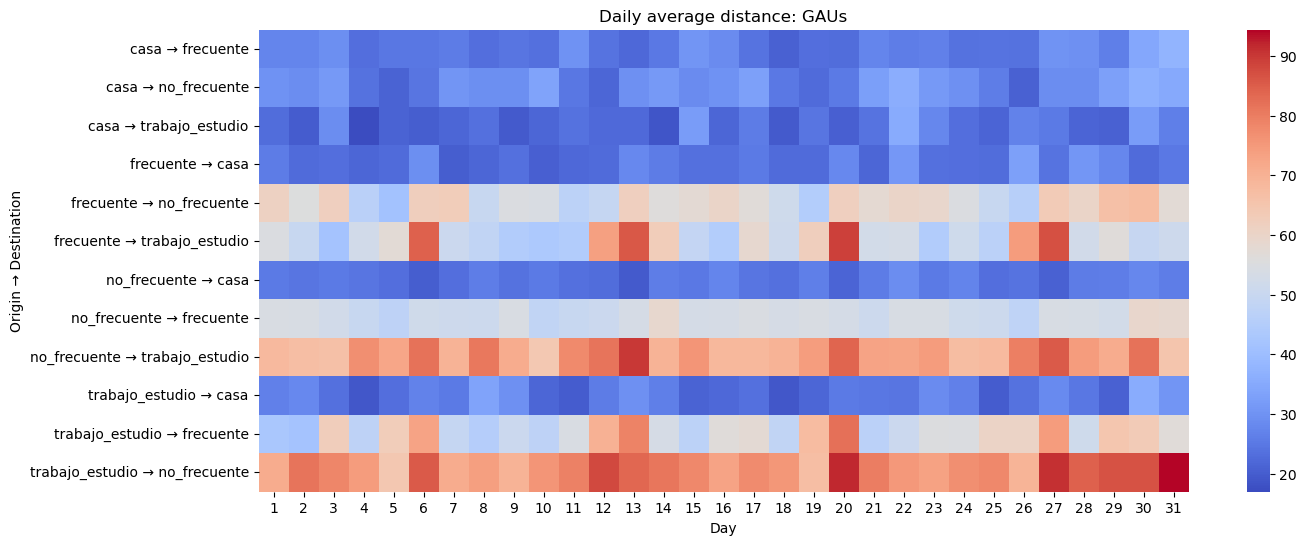

In [4]:
plt.figure(figsize=(15,6))
pivot = activity_purposes_pairs_distance_V3.pivot_table(index="purpose_pair", columns="day", values="distance", aggfunc="mean")
sns.heatmap(pivot, cmap="coolwarm")
plt.title("Daily average distance: GAUs")
plt.xlabel("Day")
plt.ylabel("Origin → Destination")
plt.show()

**INCOME**

- <10: menos de 10,000 euros.
- 10-15: entre 10,000 y 15,000 euros.
- \> 15: más de 15,000 euros.

**AGE**

- 0-24: 0-24 años
- 25-44: 25-44 años
- 45-64: 45-64 años
- \> 65: \> 65 años

In [5]:
activity_purposes_pairs_districts_ages = pd.read_csv('/data/big/davidaltamirano/results/actual_distances_oct_districts_ages.csv')
activity_purposes_pairs_districts_ages['date'] = [f'202410{str(i).zfill(2)}' for i in activity_purposes_pairs_districts_ages.day]
activity_purposes_pairs_districts_ages['datetime'] = pd.to_datetime(activity_purposes_pairs_districts_ages['date'], format='%Y%m%d')
activity_purposes_pairs_districts_ages['day_name'] = activity_purposes_pairs_districts_ages['datetime'].dt.strftime('%a')
activity_purposes_pairs_districts_ages['n_trips'] = activity_purposes_pairs_districts_ages.n_trips_W + activity_purposes_pairs_districts_ages.n_trips_M
activity_purposes_pairs_districts_ages["purpose_pair"] = activity_purposes_pairs_districts_ages["purpose_origin"] + " → " + activity_purposes_pairs_districts_ages["purpose_destination"]

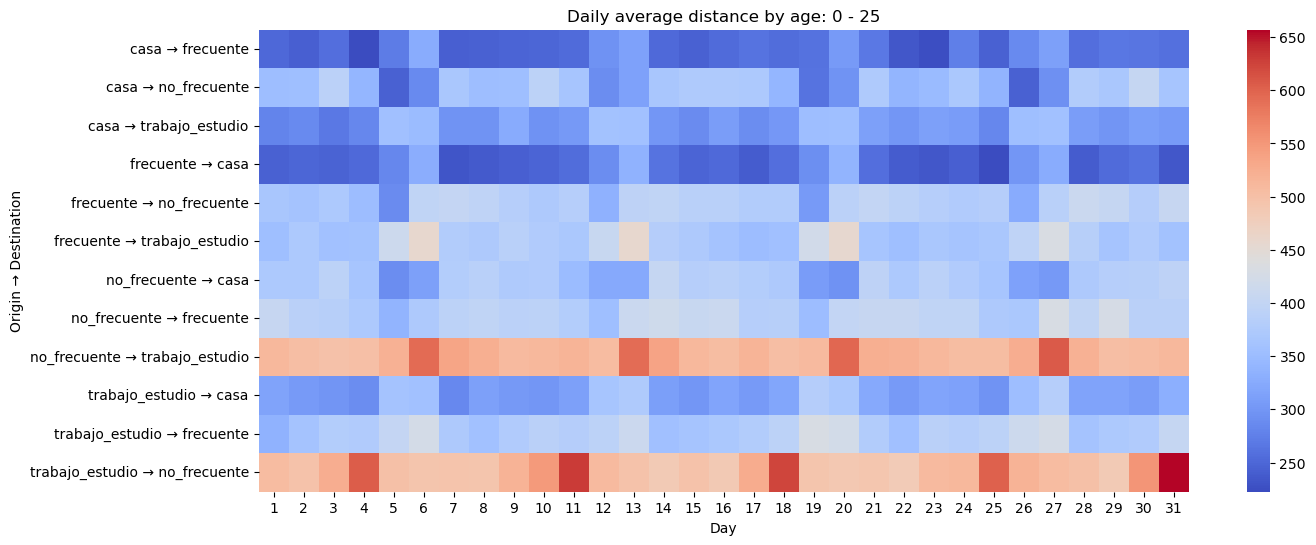

In [6]:
plt.figure(figsize=(15,6))
pivot = activity_purposes_pairs_districts_ages[activity_purposes_pairs_districts_ages.age == '0-25'].pivot_table(index="purpose_pair", columns="day", values="distance", aggfunc="mean")
sns.heatmap(pivot, cmap="coolwarm")
plt.title("Daily average distance by age: 0 - 25")
plt.xlabel("Day")
plt.ylabel("Origin → Destination")
plt.show()

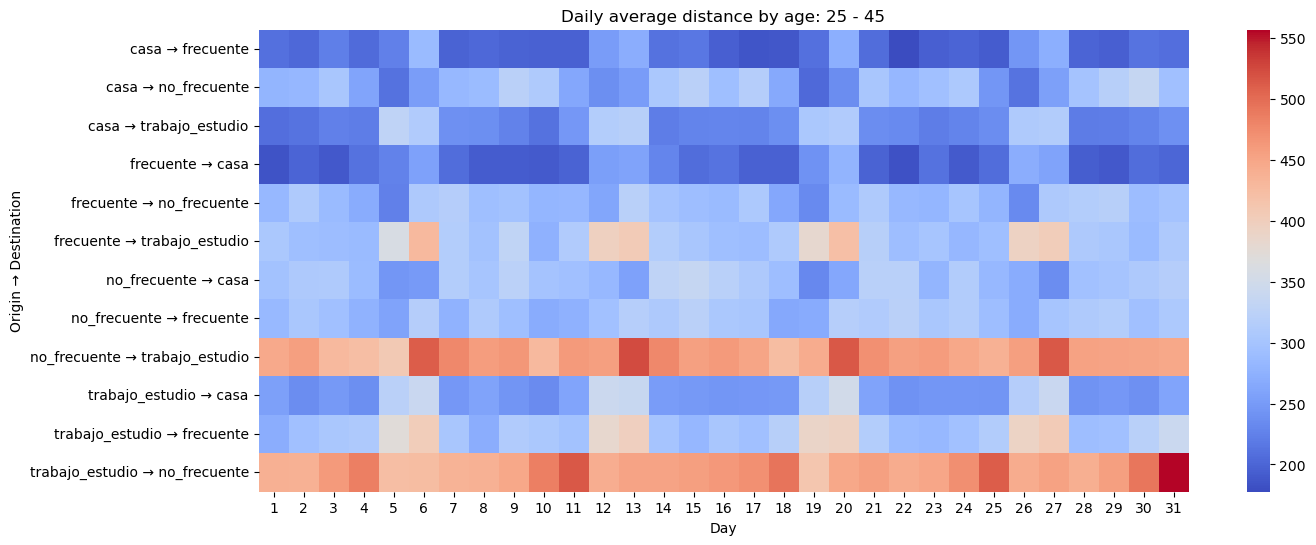

In [7]:
plt.figure(figsize=(15,6))
pivot = activity_purposes_pairs_districts_ages[activity_purposes_pairs_districts_ages.age == '25-45'].pivot_table(index="purpose_pair", columns="day", values="distance", aggfunc="mean")
sns.heatmap(pivot, cmap="coolwarm")
plt.title("Daily average distance by age: 25 - 45")
plt.xlabel("Day")
plt.ylabel("Origin → Destination")
plt.show()

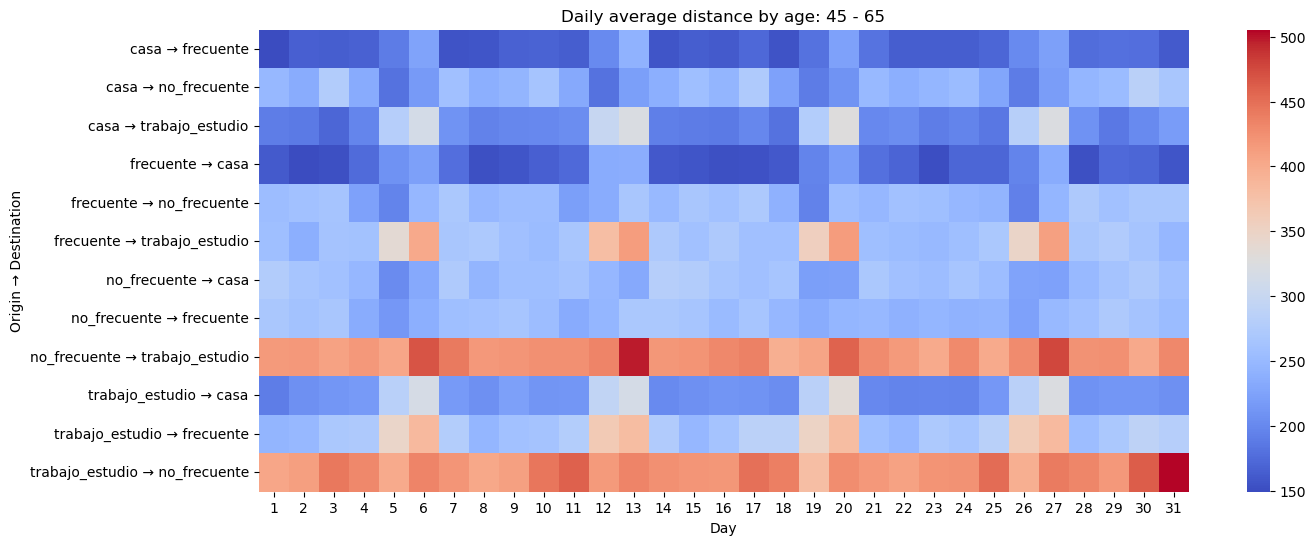

In [8]:
plt.figure(figsize=(15,6))
pivot = activity_purposes_pairs_districts_ages[activity_purposes_pairs_districts_ages.age == '45-65'].pivot_table(index="purpose_pair", columns="day", values="distance", aggfunc="mean")
sns.heatmap(pivot, cmap="coolwarm")
plt.title("Daily average distance by age: 45 - 65")
plt.xlabel("Day")
plt.ylabel("Origin → Destination")
plt.show()

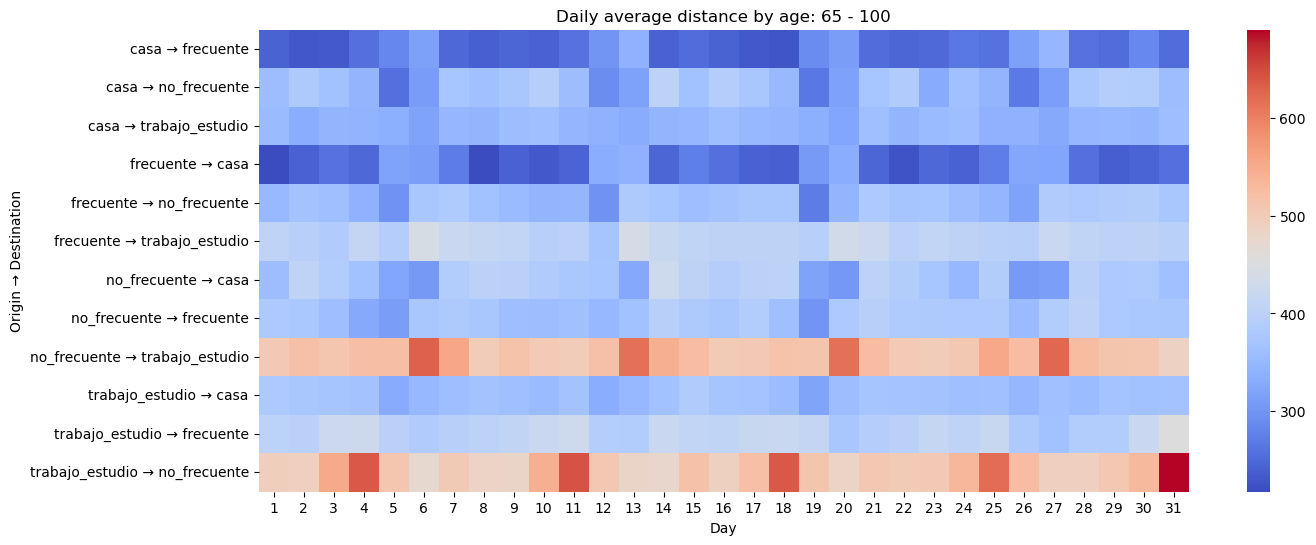

In [9]:
plt.figure(figsize=(15,6))
pivot = activity_purposes_pairs_districts_ages[activity_purposes_pairs_districts_ages.age == '65-100'].pivot_table(index="purpose_pair", columns="day", values="distance", aggfunc="mean")
sns.heatmap(pivot, cmap="coolwarm")
plt.title("Daily average distance by age: 65 - 100")
plt.xlabel("Day")
plt.ylabel("Origin → Destination")
plt.show()

### Simulation of the contribution of each node to the final distance

In [ ]:
refined_df = spark.read.parquet('/data/big/davidaltamirano/data_aggregation/2024/10/gaus_inSpain_noNAgender/') #distritos o gaus


df_to_study = (refined_df.groupBy("fecha", "periodo", "origen", "destino", "sexo")
               .agg(sum("total_trips").alias("total_trips")))#, sum("total_km").alias("total_km")))


contribution = []

for day in range(1, 32):
    day_to_study = str(day).zfill(2)

    # Filter the dataset to a specific day
    df_to_study_daily = df_to_study.filter((substring(col("fecha"), 7, 2) == day_to_study))
    dict_name = f'/data/big/davidaltamirano/results/exact_N/dict_202410{day_to_study}_oct_gaus_1_Noabroad_studyV2.pkl'

    df_to_study_daily, n, daily_dictionary = Mapping_for_Embeddding(df_to_study_daily, dict_name, save_dict=False)
    day_dict_inv = {value:key for key, value in daily_dictionary.items()}

    # Split the dataset into n (choices of the aggregation parameter) datasets
    # n for 'sexo': ['hombre', 'mujer, 'NA']
    df_woman = df_to_study_daily.filter(col('sexo') == 'mujer')
    df_man = df_to_study_daily.filter(col('sexo') == 'hombre')

    # Select the origin, destination, time and weight columns (global transition matrix) and rewrite to i, j, t and τ
    pd_df_woman = df_woman.select(col('origin_id').alias('i'), col('destination_id').alias('j'), col('periodo').alias('t'), col('total_trips').alias('\u03C4')).toPandas()
    pd_df_man = df_man.select(col('origin_id').alias('i'), col('destination_id').alias('j'), col('periodo').alias('t'), col('total_trips').alias('\u03C4')).toPandas()
    nodes_woman = pd.concat([pd_df_woman['i'], pd_df_woman['j']]).unique()
    nodes_man = pd.concat([pd_df_man['i'], pd_df_man['j']]).unique()

    nodes = np.arange(n)

    Data = Graphs4Distance(verbose=0)
    # Loading the dataset
    Data.LoadDataset(pd_df_man, 'graph_man', nodes=nodes)        # taumin=1, t_agg=24, symmetric=False
    Data.LoadDataset(pd_df_woman, 'graph_woman', nodes=nodes)    # taumin=1, t_agg=24

    dist = Data.GetDistance('graph_man', 'graph_woman', distance_type = 'matched', node_mapping = 'Same')

    adj_matrix_node_distances = (Data.graphs['graph_woman'].X @ Data.graphs['graph_woman'].X.T) - (Data.graphs['graph_man'].X @ Data.graphs['graph_man'].X.T)
    node_i_contribution = [np.sum(node) for node in (adj_matrix_node_distances**2)]

    contribution.append([day, nodes_woman, nodes_man, node_i_contribution, day_dict_inv])
    print(f'Finished day {day_to_study}')

nodes_contribution = pd.DataFrame(contribution, columns=['day', 'nodesW', 'nodesM', 'node_contribution', 'dictionary'])
nodes_contribution.to_csv('/data/big/davidaltamirano/results/node_contribution_to_distance_oct_gaus.csv')

In [ ]:
df_contribution = pd.read_csv('/data/big/davidaltamirano/results/node_contribution_to_distance_oct_gaus.csv')
gdf_GAU = gpd.read_file('/data/big/davidaltamirano/zonificacion_distritos/zonificacion_gaus.shp')
days = pd.date_range("2024-10-01", "2024-10-31", freq="D")
cmap = plt.get_cmap('coolwarm')

abroad_areas_df = pd.read_csv('/data/big/davidaltamirano/areas_out_Spain.csv')
abroad_areas = list(abroad_areas_df['ID']) 

fig, ax = plt.subplots(1, 1, figsize=(18, 8))

def update(frame):
    ax.clear()
    day = days[frame]

    node_i_contribution = df_contribution['node_contribution'].apply(ast.literal_eval).tolist()[frame]
    daily_dictionary_inv = df_contribution['dictionary'].apply(ast.literal_eval).tolist()[frame]
    max_contribution_value = max(node_i_contribution)
    
    gdf_GAU[gdf_GAU['ID'].isin(list(set(gdf_GAU['ID'])-set(abroad_areas)))].plot(ax=ax, edgecolor='lightgray', facecolor='white')
    for idx, gau in enumerate(daily_dictionary_inv.values()):
        gdf_GAU[gdf_GAU['ID'] == gau].plot(ax=ax, edgecolor=cmap(node_i_contribution[idx]/max_contribution_value), facecolor=cmap(node_i_contribution[idx]/max_contribution_value))
    ax.set_title(f"{day.strftime('%Y-%m-%d')}")
    ax.axis('off')
    ax.legend()
    # gdf_GAU[gdf_GAU['ID'].isin(max_contrib_matrix[frame])].plot(ax=ax, edgecolor='red', facecolor='white', label='Max. distance')

# Create the animation
ani = animation.FuncAnimation(fig, update, frames=len(days), interval=500, repeat=True)

# Guardar como GIF (requiere imagemagick instalado) o MP4 (ffmpeg)
ani.save("/home/daltamirano/oct_2024_districts_full.gif", writer="imagemagick")

plt.show()